# When Diversification Fails: Geopolitical Contagion and Hidden Vulnerabilities in Europe's Energy Transition

Official implementation accompanying the paper

> **When Diversification Fails: Geopolitical Contagion and Hidden Vulnerabilities in Europe's Energy Transition**


In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm
import scipy.stats as stats
from adjustText import adjust_text
from scipy.interpolate import PchipInterpolator
from scipy.optimize import minimize

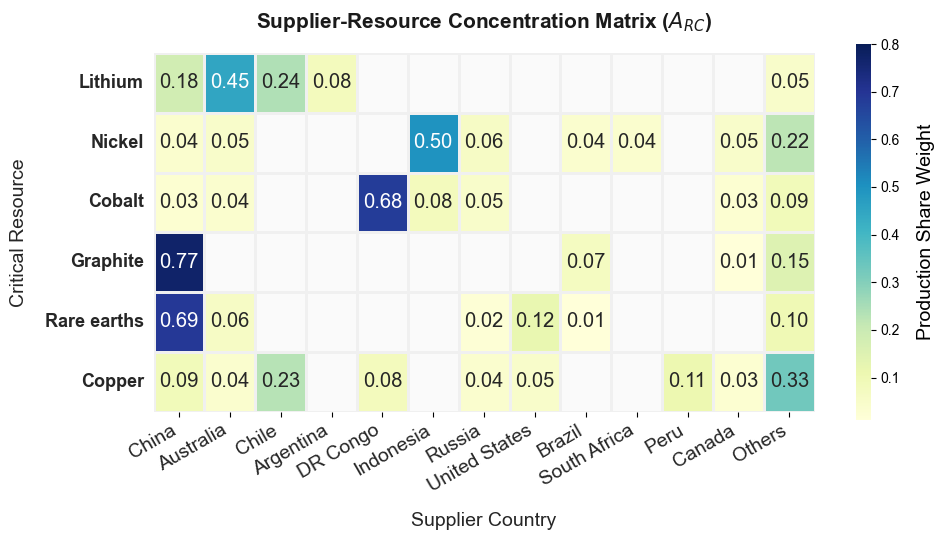

In [2]:
# ==========================================================
# Figure 1
# ==========================================================

DATA_DIR = r"C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/F01_Supplier_resource_concentration_matrix.csv"
df = pd.read_csv(DATA_DIR)

matrix = df.pivot(index="resource", columns="supplier", values="production_share").fillna(0)

resource_order = ["Lithium", "Nickel", "Cobalt", "Graphite", "Rare earths", "Copper"]
supplier_order = ["China", "Australia", "Chile", "Argentina", "DR Congo", "Indonesia", "Russia", "United States", "Brazil", "South Africa", "Peru", "Canada", "Others"]
matrix = matrix.loc[resource_order, supplier_order]

# ==========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(10, 5.5))

mask = matrix == 0

ax_heatmap = sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    mask=mask,
    linewidths=0.85,
    linecolor="#f0f0f0",
    cbar=True,
    square=False,
    annot_kws={"size": 14.5, "weight": "medium"},
    vmax=0.8,
    ax=ax,
    cbar_kws={
        "label": "Production Share Weight",
        "shrink": 1.05,
        "aspect": 25
    }
)

cbar = ax_heatmap.collections[0].colorbar
cbar.set_label("Production Share Weight", fontsize=14, labelpad=12, weight="medium")

ax.set_facecolor('#fafafa')

ax.tick_params(top=False, bottom=True, left=False, right=False, labelleft=True, labelbottom=True)

ax.set_xticklabels(supplier_order, rotation=30, ha="right", fontsize=14, color="#262626")
ax.set_yticklabels(resource_order, rotation=0, fontsize=13, color="#262626", fontweight='bold')

ax.set_xlabel("Supplier Country", fontsize=14, labelpad=12, color="#262626")
ax.set_ylabel("Critical Resource", fontsize=14, labelpad=12, color="#262626")

ax.set_title(r"Supplier-Resource Concentration Matrix ($A_{RC}$)", fontsize=15, pad=18, fontweight='bold', color="#1a1a1a")

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


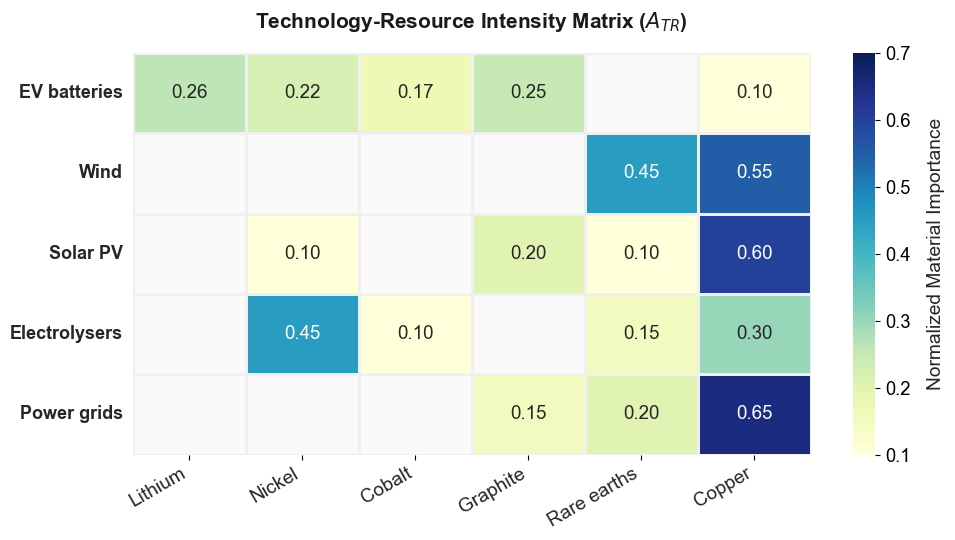

In [3]:
# ==========================================================
# Figure 2
# ==========================================================

DATA_DIR = r"C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/F02_Technology_resource_intensity_matrix.csv"

df = pd.read_csv(DATA_DIR)

matrix = df.pivot(index="technology", columns="resource", values="material_intensity").fillna(0)
technology_order = ["EV batteries", "Wind", "Solar PV", "Electrolysers", "Power grids"]
resource_order = ["Lithium", "Nickel", "Cobalt", "Graphite", "Rare earths", "Copper"]
matrix = matrix.loc[technology_order, resource_order]

# ==========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
# ==========================================================


fig, ax = plt.subplots(figsize=(10, 5.5))

mask = (matrix == 0)

ax_heatmap = sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    mask=mask,
    linewidths=1.0,
    linecolor="#f0f0f0",
    cbar=True,
    square=False,
    vmax=0.7,
    annot_kws={"size": 13.5, "weight": "medium"},
    ax=ax,
    cbar_kws={
        "shrink": 1.0,
        "aspect": 18
    }
)

ax.set_facecolor('#fafafa')

ax.tick_params(top=False, bottom=True, left=False, right=False, labelleft=True, labelbottom=True)
ax.set_xticklabels(resource_order, rotation=30, ha="right", fontsize=13.8, color="#262626")
ax.set_yticklabels(technology_order, rotation=0, fontsize=13, color="#262626", fontweight='bold')

ax.set_xlabel("", fontsize=13.5)
ax.set_ylabel("", fontsize=13.5)

ax.set_title(r"Technology-Resource Intensity Matrix ($A_{TR}$)", fontsize=15, pad=18, fontweight='bold', color="#1a1a1a")

cbar = ax_heatmap.collections[0].colorbar
cbar.set_label("Normalized Material Importance", fontsize=13.8, labelpad=12, weight="medium", color="#262626")
cbar.ax.tick_params(labelsize=13.2)
cbar.outline.set_visible(False)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


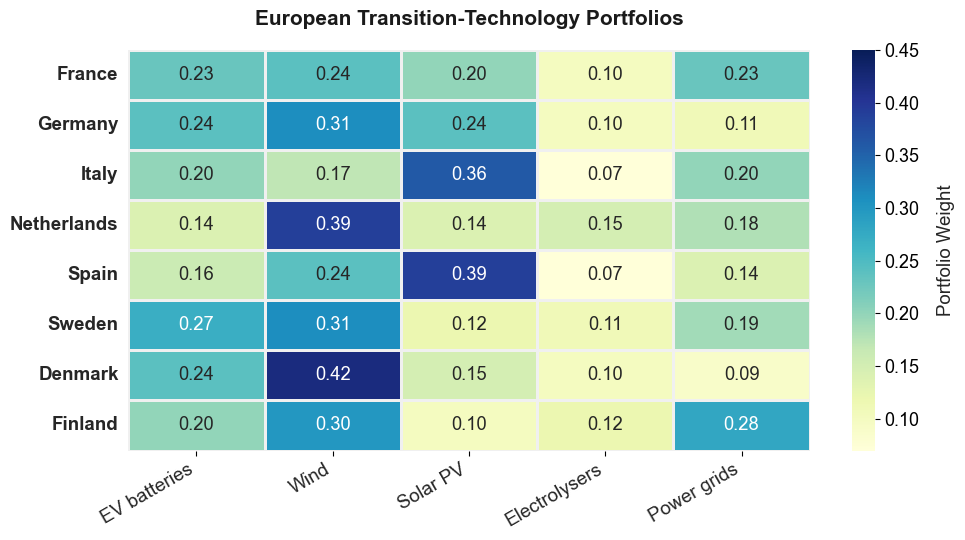

In [4]:
# ==========================================================
# Figure 3
# ==========================================================


DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/extended_nordic_8/F03_transition_technology_portfolios.csv"


df = pd.read_csv(DATA_DIR)

matrix = df.pivot(index="economy", columns="technology", values="portfolio_weight")

economy_order = ["France", "Germany", "Italy", "Netherlands", "Spain", "Sweden", "Denmark", "Finland"]
technology_order = ["EV batteries", "Wind", "Solar PV", "Electrolysers", "Power grids"]
matrix = matrix.reindex(index=economy_order, columns=technology_order)

# ==========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(10, 5.5))

ax_heatmap = sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=1.0,
    linecolor="#f0f0f0",
    cbar=True,
    square=False,
    vmax=0.45,
    annot_kws={"size": 13.2, "weight": "medium"},
    ax=ax,
    cbar_kws={
        "shrink": 1.0,
        "aspect": 18
    }
)

ax.tick_params(top=False, bottom=True, left=False, right=False, labelleft=True, labelbottom=True)
ax.set_xticklabels(technology_order, rotation=30, ha="right", fontsize=13.6, color="#262626")
ax.set_yticklabels(economy_order, rotation=0, fontsize=13.5, color="#262626", fontweight='bold')

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_title(r"European Transition-Technology Portfolios", fontsize=15, pad=18, fontweight='bold', color="#1a1a1a")

cbar = ax_heatmap.collections[0].colorbar
cbar.set_label("Portfolio Weight", fontsize=13.4, labelpad=13, weight="medium", color="#262626")
cbar.ax.tick_params(labelsize=13)
cbar.outline.set_visible(False)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


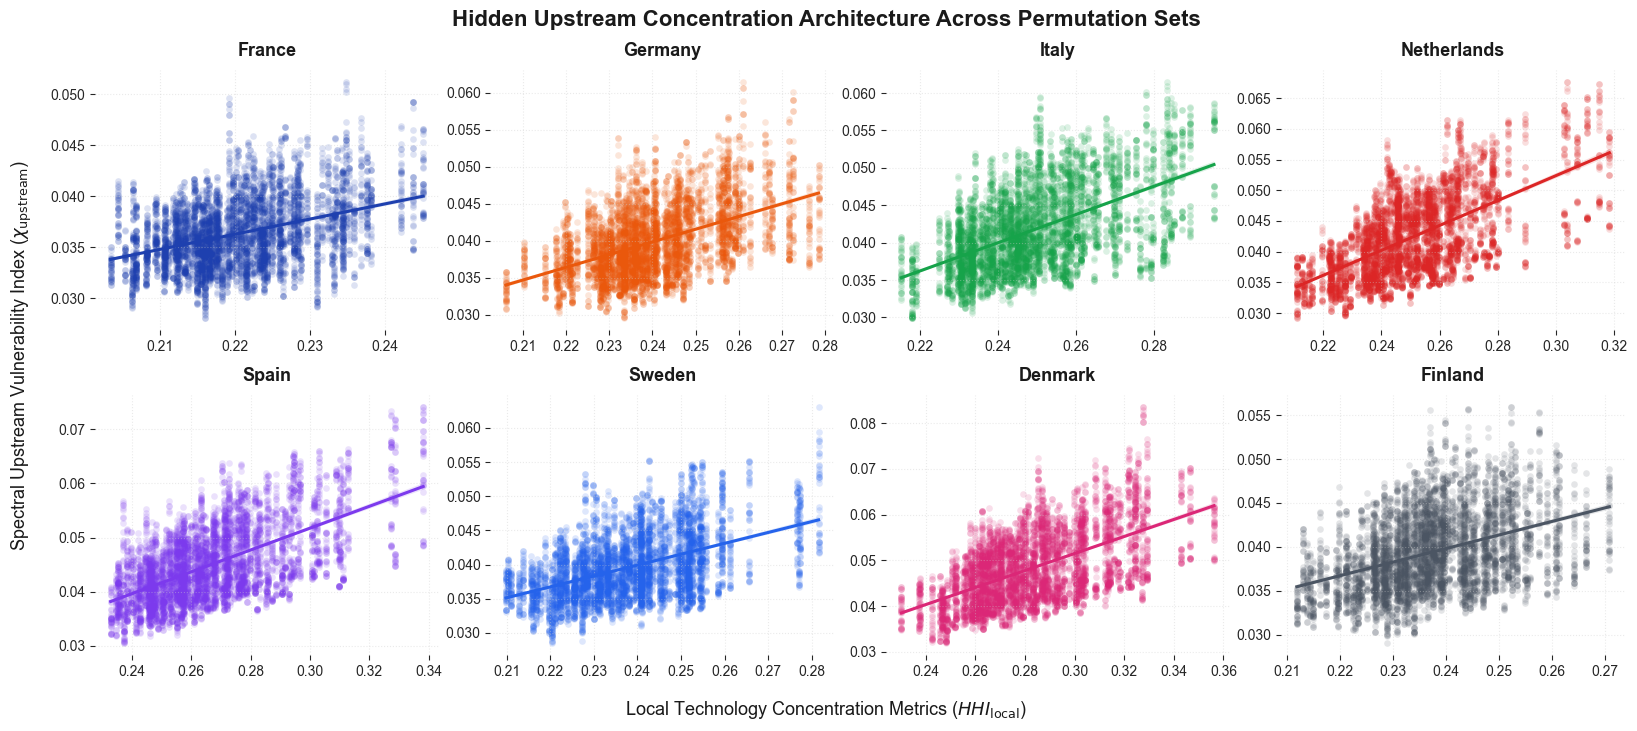

In [5]:
# ==========================================================
# Figure 4
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/extended_nordic_8/F04_hidden_upstream_concentration.csv"

df = pd.read_csv(DATA_DIR)
df["economy"] = pd.Categorical(df["economy"], categories=economy_order, ordered=True)

# ==========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

academic_palette = ["#1e40af", "#ea580c", "#16a34a", "#dc2626", "#7c3aed", "#2563eb", "#db2777", "#4b5563"]

fig, axes = plt.subplots(2, 4, figsize=(17, 7.5), sharex=False, sharey=False)
axes_flat = axes.flatten()

# ==========================================================
for idx, economy in enumerate(economy_order):
    ax = axes_flat[idx]
    subset = df[df["economy"] == economy]
    color = academic_palette[idx]

    sns.regplot(
        data=subset,
        x="HHI",
        y="chi",
        ax=ax,
        color=color,
        scatter_kws={"s": 23, "alpha": 0.15, "linewidths": 0},
        line_kws={"linewidth": 2.2}
    )

    ax.set_title(economy, fontsize=13, weight="bold", color="#1a1a1a", pad=10)

    ax.grid(True, linestyle=":", alpha=0.4, color="#cccccc")
    ax.tick_params(axis="both", labelsize=10, colors="#262626")

    ax.set_xlabel("")
    ax.set_ylabel("")

    # Rendre les contours transparents pour un style épuré
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

# ==========================================================
fig.text(
    0.5, 0.02,
    r"Local Technology Concentration Metrics ($HHI_{\mathrm{local}}$)",
    ha="center", fontsize=13, color="#1a1a1a"
)

fig.text(
    0.02, 0.5,
    r"Spectral Upstream Vulnerability Index ($\chi_{\mathrm{upstream}}$)",
    va="center", rotation="vertical", fontsize=13, color="#1a1a1a"
)

fig.suptitle(
    "Hidden Upstream Concentration Architecture Across Permutation Sets",
    fontsize=16,
    weight="bold",
    color="#1a1a1a",
    y=0.96
)

plt.subplots_adjust(left=0.07, right=0.97, bottom=0.10, top=0.88, hspace=0.25, wspace=0.15)

plt.show()



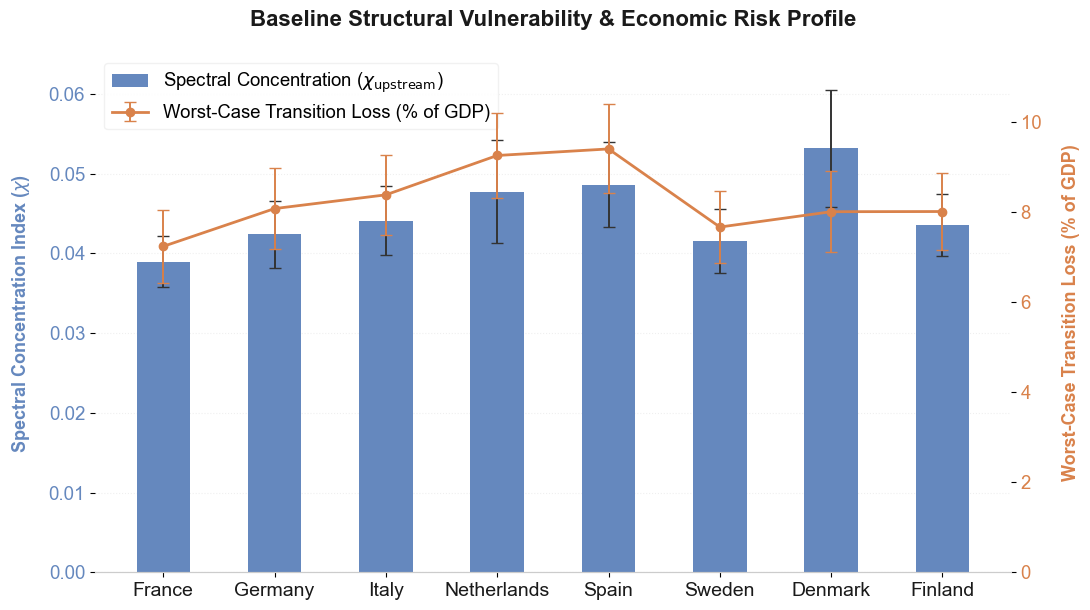

In [6]:
# ==========================================================
# Figure 5
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/extended_nordic_8/F05_baseline_structural_vulnerability.csv"
df = pd.read_csv(DATA_DIR)

required_columns = {
    "economy",
    "chi_mean",
    "chi_std",
    "worstcase_loss_pct_mean",
    "worstcase_loss_pct_std",
}

missing_columns = required_columns.difference(df.columns)

economy_order = [
    "France",
    "Germany",
    "Italy",
    "Netherlands",
    "Spain",
    "Sweden",
    "Denmark",
    "Finland",
]

missing_economies = [
    economy
    for economy in economy_order
    if economy not in df["economy"].unique()]

plot_df = (
    df.set_index("economy")
    .loc[economy_order]
    .reset_index())

# ==========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

fig, ax1 = plt.subplots(figsize=(11, 6.2))
ax2 = ax1.twinx()

x = np.arange(len(economy_order))
bar_width = 0.48

color_blue = "#6588be"
color_orange = "#d9824b"

bars = ax1.bar(
    x,
    plot_df["chi_mean"],
    width=bar_width,
    color=color_blue,
    label=r"Spectral Concentration ($\chi_{\mathrm{upstream}}$)",
    zorder=2
)

ax1.errorbar(
    x,
    plot_df["chi_mean"],
    yerr=plot_df["chi_std"],
    fmt='none',
    ecolor="#333333",
    elinewidth=1.4,
    capsize=4,
    zorder=3
)

line = ax2.errorbar(
    x,
    plot_df["worstcase_loss_pct_mean"],
    yerr=plot_df["worstcase_loss_pct_std"],
    color=color_orange,
    marker="o",
    markersize=6,
    linewidth=2,
    elinewidth=1.4,
    capsize=4,
    label="Worst-Case Transition Loss (% of GDP)",
    zorder=4
)

# ==========================================================

ax1.grid(True, axis="y", linestyle=":", alpha=0.3, color="#cccccc", zorder=1)
ax1.set_axisbelow(True)

ax1.set_xticks(x)
ax1.set_xticklabels(economy_order, fontsize=14, color="#1a1a1a")

ax1.set_ylabel(r"Spectral Concentration Index ($\chi$)", fontsize=13, color=color_blue, fontweight="bold", labelpad=12)
ax1.tick_params(axis="y", labelcolor=color_blue, labelsize=13.5)
ax1.set_ylim(0, 0.065)

ax2.set_ylabel("Worst-Case Transition Loss (% of GDP)", fontsize=13, color=color_orange, fontweight="bold", labelpad=15)
ax2.tick_params(axis="y", labelcolor=color_orange, labelsize=13.3)
ax2.set_ylim(0, 11.5)

for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")

# ==========================================================

lines_labels = [bars, line]
labels = [l.get_label() for l in lines_labels]
ax1.legend(
    lines_labels,
    labels,
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#f0f0f0",
    framealpha=0.9,
    fontsize=13.3
)

ax1.set_title(
    "Baseline Structural Vulnerability & Economic Risk Profile",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#1a1a1a"
)

plt.tight_layout()
plt.show()



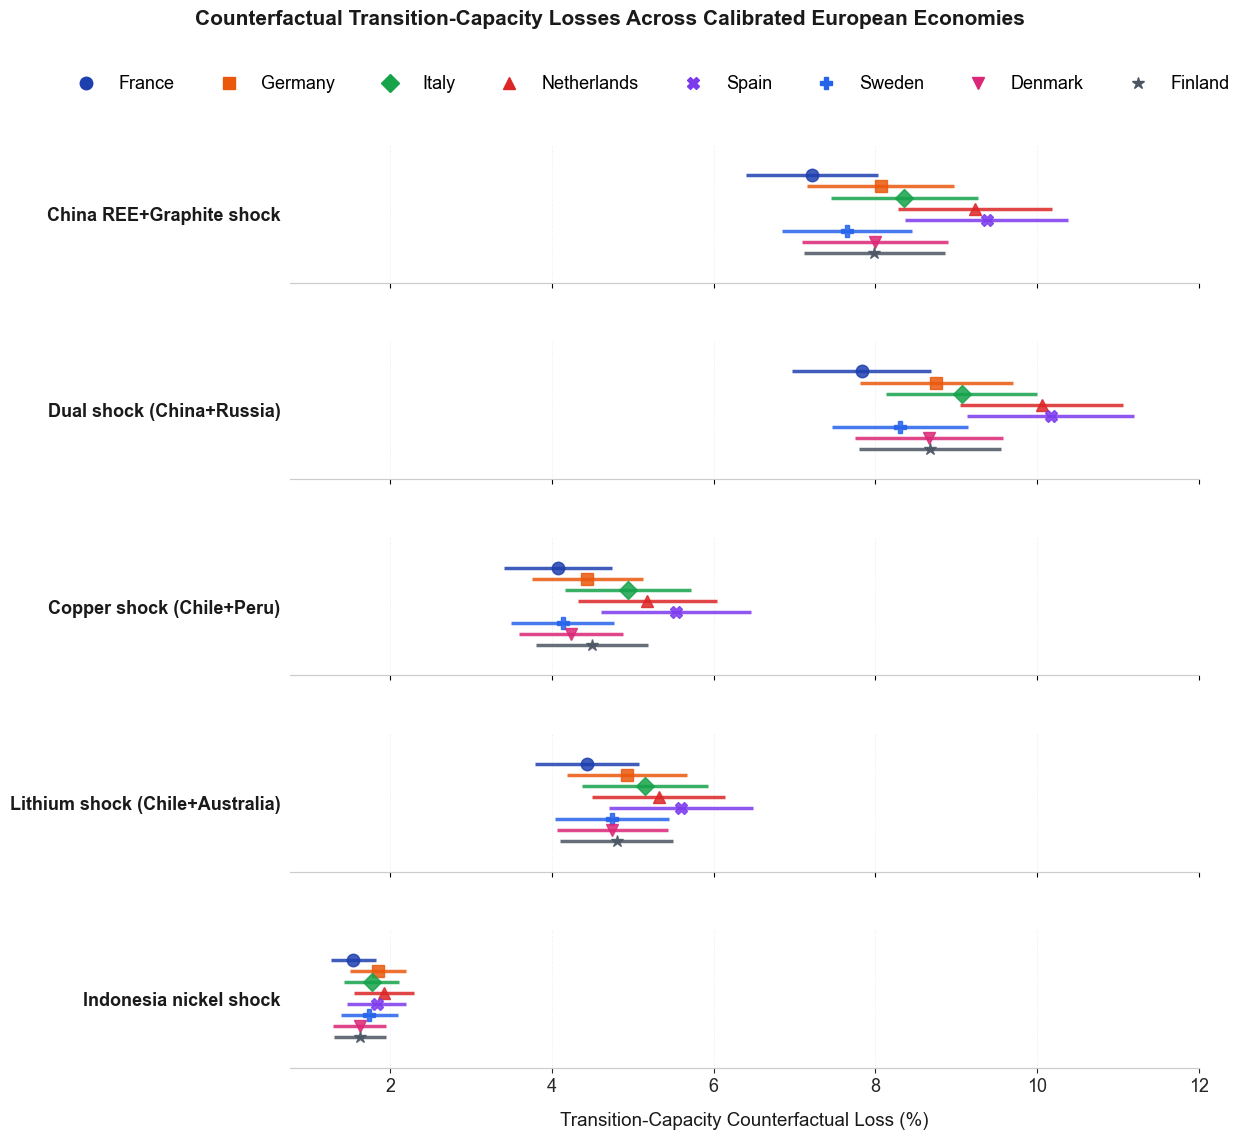

In [7]:
# ==========================================================
# Figure 6
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/extended_nordic_8/F06_counterfactual_shock_losses.csv"

df = pd.read_csv(DATA_DIR)

scenario_order = [
    "China REE+Graphite shock",
    "Dual shock (China+Russia)",
    "Copper shock (Chile+Peru)",
    "Lithium shock (Chile+Australia)",
    "Indonesia nickel shock",
]
economy_order = ["France", "Germany", "Italy", "Netherlands", "Spain", "Sweden", "Denmark", "Finland"]

df["scenario"] = pd.Categorical(df["scenario"], categories=scenario_order, ordered=True)
df["economy"] = pd.Categorical(df["economy"], categories=economy_order, ordered=True)
df = df.sort_values(["scenario", "economy"])

# ==========================================================
academic_palette = ["#1e40af", "#ea580c", "#16a34a", "#dc2626", "#7c3aed", "#2563eb", "#db2777", "#4b5563"]
markers = {
    "France": "o", "Germany": "s", "Italy": "D", "Netherlands": "^",
    "Spain": "X", "Sweden": "P", "Denmark": "v", "Finland": "*"
}

n_scenarios = len(scenario_order)


fig, axes = plt.subplots(nrows=n_scenarios, ncols=1, figsize=(12.8, 12.3), sharex=True)

offsets = np.linspace(0.18, -0.18, len(economy_order))

for ax, scenario in zip(axes, scenario_order):
    subset = df[df["scenario"] == scenario]

    for idx, (offset, economy) in enumerate(zip(offsets, economy_order)):
        row = subset[subset["economy"] == economy]
        if row.empty:
            continue

        mean_value = row["mean"].iloc[0]
        std_value = row["std"].iloc[0]
        color = academic_palette[idx]

        ax.errorbar(
            mean_value,
            offset,
            xerr=std_value,
            fmt=markers[economy],
            color=color,
            markersize=9,
            capsize=0,
            elinewidth=2.5,
            linewidth=0,
            alpha=0.85
        )

    # Labeling and Clean Y-axis
    ax.set_yticks([0])
    ax.set_yticklabels([scenario], fontsize=13, fontweight="bold", color="#1a1a1a")
    ax.tick_params(axis="y", which="both", left=False, right=False)
    ax.set_ylim(-0.32, 0.32)

    # X-Grid styling
    ax.grid(axis="x", linestyle=":", linewidth=0.7, alpha=0.4, color="#cccccc")

    # Spine Cleaning
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.spines["bottom"].set_linewidth(0.85)

xmin = max(0, (df["mean"] - df["std"]).min() - 0.5)
xmax = (df["mean"] + df["std"]).max() + 0.8
axes[-1].set_xlim(xmin, xmax)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

axes[-1].set_xlabel("Transition-Capacity Counterfactual Loss (%)", fontsize=13.5, fontweight="medium", labelpad=12,
                    color="#1a1a1a")
axes[-1].tick_params(axis="x", labelsize=13, colors="#262626")

# ==========================================================
legend_handles = [
    Line2D(
        [0], [0],
        marker=markers[economy],
        color=academic_palette[i],
        linestyle="none",
        markersize=9,
        label=economy
    )
    for i, economy in enumerate(economy_order)
]

fig.legend(
    handles=legend_handles,
    labels=economy_order,
    loc="upper center",
    bbox_to_anchor=(0.53, 0.92),
    ncol=8,
    frameon=False,
    fontsize=13
)

fig.suptitle(
    "Counterfactual Transition-Capacity Losses Across Calibrated European Economies",
    fontsize=15,
    fontweight="bold",
    color="#1a1a1a",
    y=0.96
)

plt.subplots_adjust(
    top=0.85,
    bottom=0.10,
    left=0.25,
    right=0.96,
    hspace=0.42
)

plt.show()



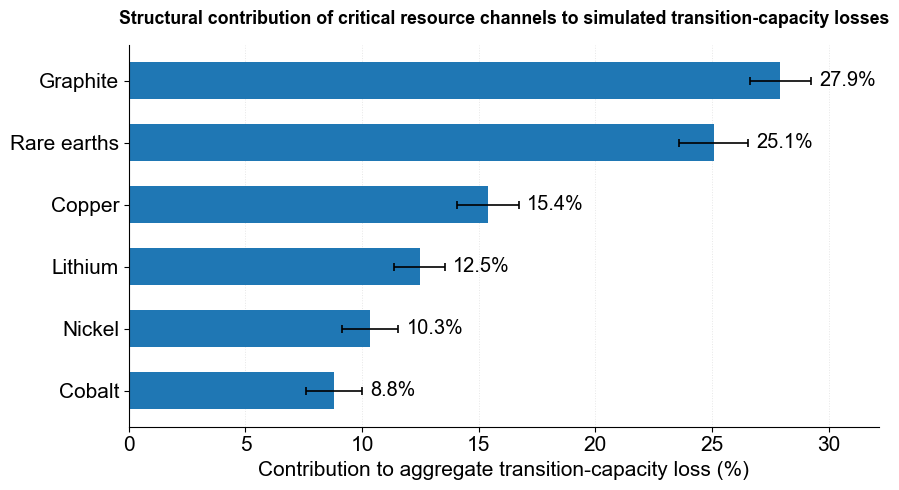

In [8]:
# ==========================================================
# Figure 7
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/extended_nordic_8/F07_resource_channel_contribution.csv"
df = pd.read_csv(DATA_DIR)

required_columns = {
    "resource",
    "mean",
    "std",
}

missing_columns = required_columns.difference(df.columns)

# ==========================================================

df["contribution_pct"] = 100.0 * df["mean"]
df["std_pct"] = 100.0 * df["std"]

# ==========================================================

resource_order = [
    "Graphite",
    "Rare earths",
    "Copper",
    "Lithium",
    "Nickel",
    "Cobalt",
]

missing_resources = [
    resource
    for resource in resource_order
    if resource not in df["resource"].unique()
]

plot_df = (
    df.set_index("resource")
    .loc[resource_order]
    .reset_index()
)

y = np.arange(len(resource_order))
# ==========================================================

fig, ax = plt.subplots(figsize=(9., 5.))
bars = ax.barh(
    y,
    plot_df["contribution_pct"],
    xerr=plot_df["std_pct"],
    height=0.60,
    capsize=3,
    error_kw={
        "elinewidth": 1.2,
        "capthick": 1.2,
    },
)
ax.invert_yaxis()

# ==========================================================
ax.set_yticks(y)
ax.set_yticklabels(
    resource_order,
    fontsize=15)

ax.set_xlabel(
    "Contribution to aggregate transition-capacity loss (%)",
    fontsize=15)

ax.set_title(
    "Structural contribution of critical resource channels to simulated transition-capacity losses",
    fontsize=12.8,
    fontweight="semibold",
    pad=15)

ax.tick_params(axis="x", labelsize=15,)

upper_limit = (
    plot_df["contribution_pct"]
    + plot_df["std_pct"]).max()

ax.set_xlim(0, max(31.5, 1.10 * upper_limit),)

ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
    alpha=0.30,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ==========================================================

for bar, value, error in zip(
    bars,
    plot_df["contribution_pct"],
    plot_df["std_pct"],
):
    ax.text(
        value + error + 0.35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=14.4,
    )

fig.tight_layout()

plt.show()



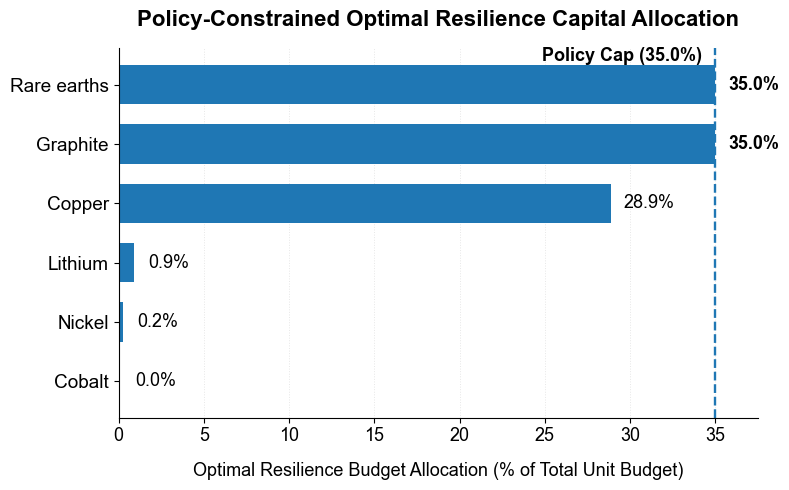

In [9]:
# ==========================================================
# Figure 8 A
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/F08_Resilience_priority_ranking_by_critical_resource.csv"
df = pd.read_csv(DATA_DIR)


TOTAL_BUDGET = 1.0
ALPHA = 0.55
POLICY_CAP = 0.35


required_columns = {
    "resource",
    "mean",
    "std",
}

missing_columns = required_columns.difference(df.columns)

# ==========================================================
# Resource order used in the manuscript
# ==========================================================

resource_order = [
    "Rare earths",
    "Graphite",
    "Copper",
    "Lithium",
    "Nickel",
    "Cobalt",
]

missing_resources = [
    resource
    for resource in resource_order
    if resource not in df["resource"].unique()
]

if missing_resources:
    raise ValueError(
        "Missing resources: "
        + ", ".join(missing_resources)
    )

allocation_df = (
    df.set_index("resource")
    .loc[resource_order]
    .reset_index()
)

marginal_benefits = allocation_df["mean"].to_numpy(dtype=float)
n_resources = len(allocation_df)

# ==========================================================

def resilience_value(allocation: np.ndarray) -> float:
    """
    Total resilience benefit:
        sum_r g_r * u_r^alpha
    """
    safe_allocation = np.maximum(allocation, 0.0)

    return float(
        np.sum(
            marginal_benefits
            * np.power(safe_allocation, ALPHA)
        )
    )


def objective(allocation: np.ndarray) -> float:
    """
    scipy.optimize minimizes, so return the negative benefit.
    """
    return -resilience_value(allocation)


constraints = [
    {
        "type": "eq",
        "fun": lambda allocation: (
            np.sum(allocation) - TOTAL_BUDGET
        ),
    }
]

bounds = [
    (0.0, POLICY_CAP)
    for _ in range(n_resources)
]

initial_allocation = np.full(
    n_resources,
    TOTAL_BUDGET / n_resources,
)

result = minimize(
    objective,
    x0=initial_allocation,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "ftol": 1e-12,
        "maxiter": 10_000,
        "disp": False,
    },
)


optimal_allocation = np.clip(
    result.x,
    0.0,
    POLICY_CAP,
)

# Remove tiny numerical residuals
optimal_allocation[
    np.abs(optimal_allocation) < 1e-8
] = 0.0

# Re-normalize only for negligible numerical error
allocation_sum = optimal_allocation.sum()

allocation_df["allocation"] = optimal_allocation
allocation_df["allocation_pct"] = (
    100.0 * allocation_df["allocation"]
)

allocation_df["cap_binding"] = np.isclose(
    allocation_df["allocation"],
    POLICY_CAP,
    atol=1e-6,
)

# ==========================================================
# Plot
# ==========================================================

y = np.arange(n_resources)

fig, ax = plt.subplots(figsize=(8., 5.))

bars = ax.barh(
    y,
    allocation_df["allocation_pct"],
    height=0.66,
)

ax.invert_yaxis()

# ==========================================================
# Policy-cap line
# ==========================================================

policy_cap_pct = 100.0 * POLICY_CAP

ax.axvline(
    policy_cap_pct,
    linestyle="--",
    linewidth=1.7,
)

ax.text(
    policy_cap_pct - 0.8,
    -0.48,
    f"Policy Cap ({policy_cap_pct:.1f}%)",
    ha="right",
    va="center",
    fontsize=13,
    fontweight="semibold",
)

# ==========================================================
# Resource labels
# ==========================================================

ax.set_yticks(y)

ax.set_yticklabels(
    allocation_df["resource"],
    fontsize=13.6,
)

# ==========================================================
# Allocation labels
# ==========================================================

for bar, allocation_pct in zip(
    bars,
    allocation_df["allocation_pct"],
):
    y_position = (
        bar.get_y()
        + bar.get_height() / 2
    )

    if allocation_pct >= policy_cap_pct - 0.05:
        x_position = allocation_pct + 0.75
        horizontal_alignment = "left"

    elif allocation_pct >= 1.0:
        x_position = allocation_pct + 0.75
        horizontal_alignment = "left"

    else:
        x_position = max(
            allocation_pct + 0.85,
            1.0,
        )
        horizontal_alignment = "left"

    ax.text(
        x_position,
        y_position,
        f"{allocation_pct:.1f}%",
        va="center",
        ha=horizontal_alignment,
        fontsize=13,
        fontweight=(
            "semibold"
            if allocation_pct >= policy_cap_pct - 0.05
            else "normal"
        ),
    )

# ==========================================================
# Titles and axes
# ==========================================================

ax.set_title(
    "Policy-Constrained Optimal Resilience Capital Allocation",
    fontsize=16,
    fontweight="semibold",
    pad=16,
)

ax.set_xlabel("Optimal Resilience Budget Allocation " "(% of Total Unit Budget)",
    fontsize=13,labelpad=12,)

ax.set_xlim(0, 37.5,)

ax.tick_params(
    axis="x",
    labelsize=13,
)

ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
    alpha=0.30,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()


plt.show()



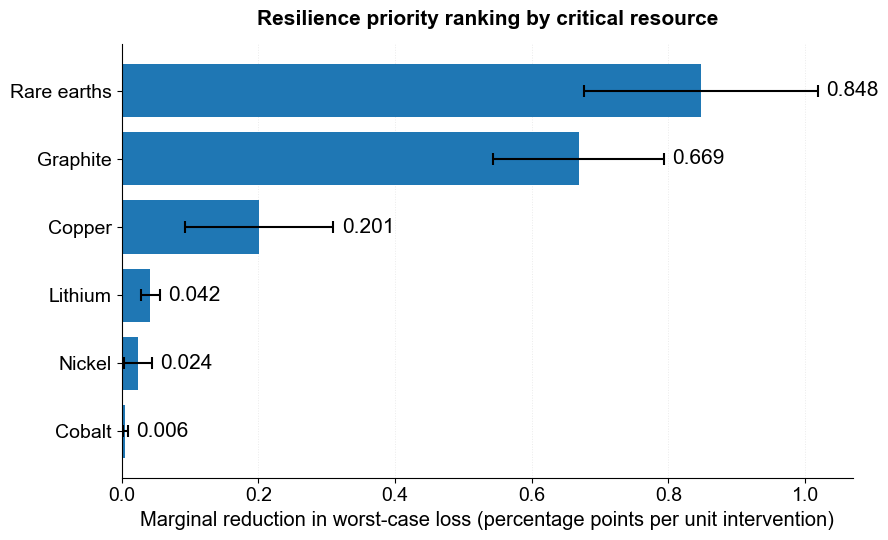

In [10]:
# ==========================================================
# Figure 8 B
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/F08_Resilience_priority_ranking_by_critical_resource.csv"
df = pd.read_csv(DATA_DIR)


required_columns = {
    "resource",
    "mean",
    "std",
}

missing_columns = required_columns.difference(df.columns)


resource_order = [
    "Rare earths",
    "Graphite",
    "Copper",
    "Lithium",
    "Nickel",
    "Cobalt",
]

missing_resources = [
    resource
    for resource in resource_order
    if resource not in df["resource"].unique()
]

if missing_resources:
    raise ValueError(
        "Missing resources: "
        + ", ".join(missing_resources)
    )

plot_df = (
    df.set_index("resource")
    .loc[resource_order]
    .reset_index()
)

# ==========================================================

y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(9., 5.5))

bars = ax.barh(
    y,
    plot_df["mean"],
    xerr=plot_df["std"],
    height=0.78,
    capsize=4,
    error_kw={
        "elinewidth": 1.5,
        "capthick": 1.5,
    },
)

ax.invert_yaxis()

# ==========================================================

ax.set_yticks(y)

ax.set_yticklabels(
    plot_df["resource"],
    fontsize=14,
)

ax.set_xlabel(
    "Marginal reduction in worst-case loss "
    "(percentage points per unit intervention)",
    fontsize=14.5,
)

ax.set_title(
    "Resilience priority ranking by critical resource",
    fontsize=15,
    fontweight="semibold",
    pad=14,
)

ax.tick_params(
    axis="x",
    labelsize=14,
)

upper_limit = (
    plot_df["mean"]
    + plot_df["std"]).max()

ax.set_xlim(
    0,
    max(1.07, 1.05 * upper_limit),
)

ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ==========================================================

for bar, mean_value, std_value in zip(
    bars,
    plot_df["mean"],
    plot_df["std"],
):
    x_position = mean_value + std_value + 0.012

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{mean_value:.3f}",
        ha="left",
        va="center",
        fontsize=15.,
    )


fig.tight_layout()

plt.show()



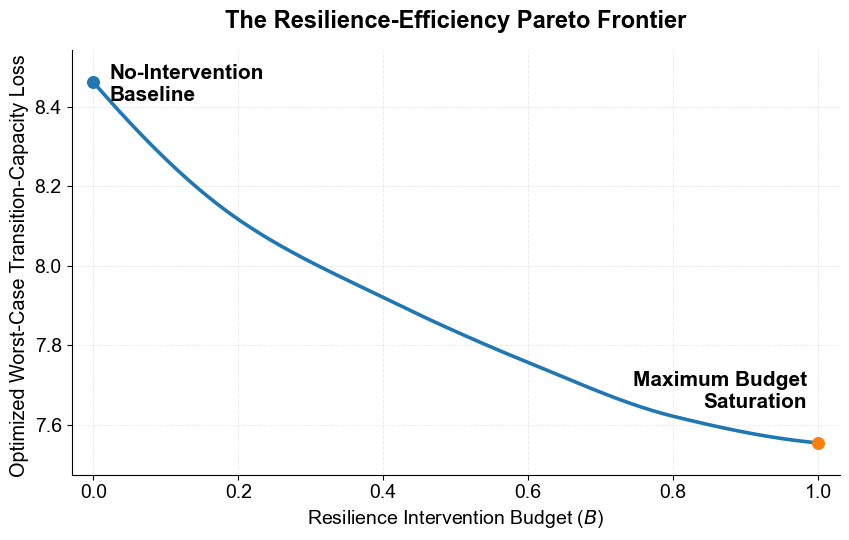

In [11]:
# ==========================================================
# Figure 9 A
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/04_Appendix/Tables/Table_resilience_efficiency_frontier.csv"
df = pd.read_csv(DATA_DIR)

# ==========================================================

required_columns = {
    "sample",
    "budget",
    "baseline_worstcase_loss_pct",
    "optimized_worstcase_loss_pct",
    "total_resilience_gain_pp",
    "relative_loss_reduction_pct",
    "alpha",
    "policy_cap",
}

missing_columns = required_columns.difference(df.columns)


numeric_columns = [
    "budget",
    "baseline_worstcase_loss_pct",
    "optimized_worstcase_loss_pct",
    "total_resilience_gain_pp",
    "relative_loss_reduction_pct",
    "alpha",
    "policy_cap",
]

# ==========================================================

plot_df = (
    df.loc[df["sample"] == "baseline_5"]
    .sort_values("budget")
    .copy()
)

budget = plot_df["budget"].to_numpy(dtype=float)
optimized_loss = plot_df["optimized_worstcase_loss_pct"].to_numpy(dtype=float)

baseline_loss = float(plot_df["baseline_worstcase_loss_pct"].iloc[0])

# ==========================================================

interpolator = PchipInterpolator(
    budget,
    optimized_loss,
)

budget_grid = np.linspace(
    budget.min(),
    budget.max(),
    400,
)

loss_grid = interpolator(budget_grid)

# ==========================================================

fig, ax = plt.subplots(figsize=(8.6, 5.5))

ax.plot(
    budget_grid,
    loss_grid,
    linewidth=2.6,
)

ax.scatter(
    budget[0],
    optimized_loss[0],
    s=70,
    zorder=4,
)

ax.scatter(
    budget[-1],
    optimized_loss[-1],
    s=70,
    zorder=4,
)

# ==========================================================

ax.annotate(
    "No-Intervention\nBaseline",
    xy=(budget[0], optimized_loss[0]),
    xytext=(12, -2),
    textcoords="offset points",
    ha="left",
    va="center",
    fontsize=15,
    fontweight="semibold",
)

ax.annotate(
    "Maximum Budget\nSaturation",
    xy=(budget[-1], optimized_loss[-1]+ 0.05),
    xytext=(-8, 8),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=15,
    fontweight="semibold",
)

# ==========================================================
ax.set_title(
    "The Resilience-Efficiency Pareto Frontier",
    fontsize=17,
    fontweight="semibold",
    pad=16,
)

ax.set_xlabel(
    r"Resilience Intervention Budget ($B$)",
    fontsize=14,
)

ax.set_ylabel(
    r"Optimized Worst-Case Transition-Capacity Loss ",
    fontsize=14.3,
)

ax.set_xlim(
    -0.03,
    1.03,
)

y_padding = 0.08

ax.set_ylim(
    optimized_loss.min() - y_padding,
    optimized_loss.max() + y_padding,
)

ax.tick_params(
    axis="both",
    labelsize=14,
)

ax.grid(
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# ==========================================================
fig.tight_layout()

plt.show()



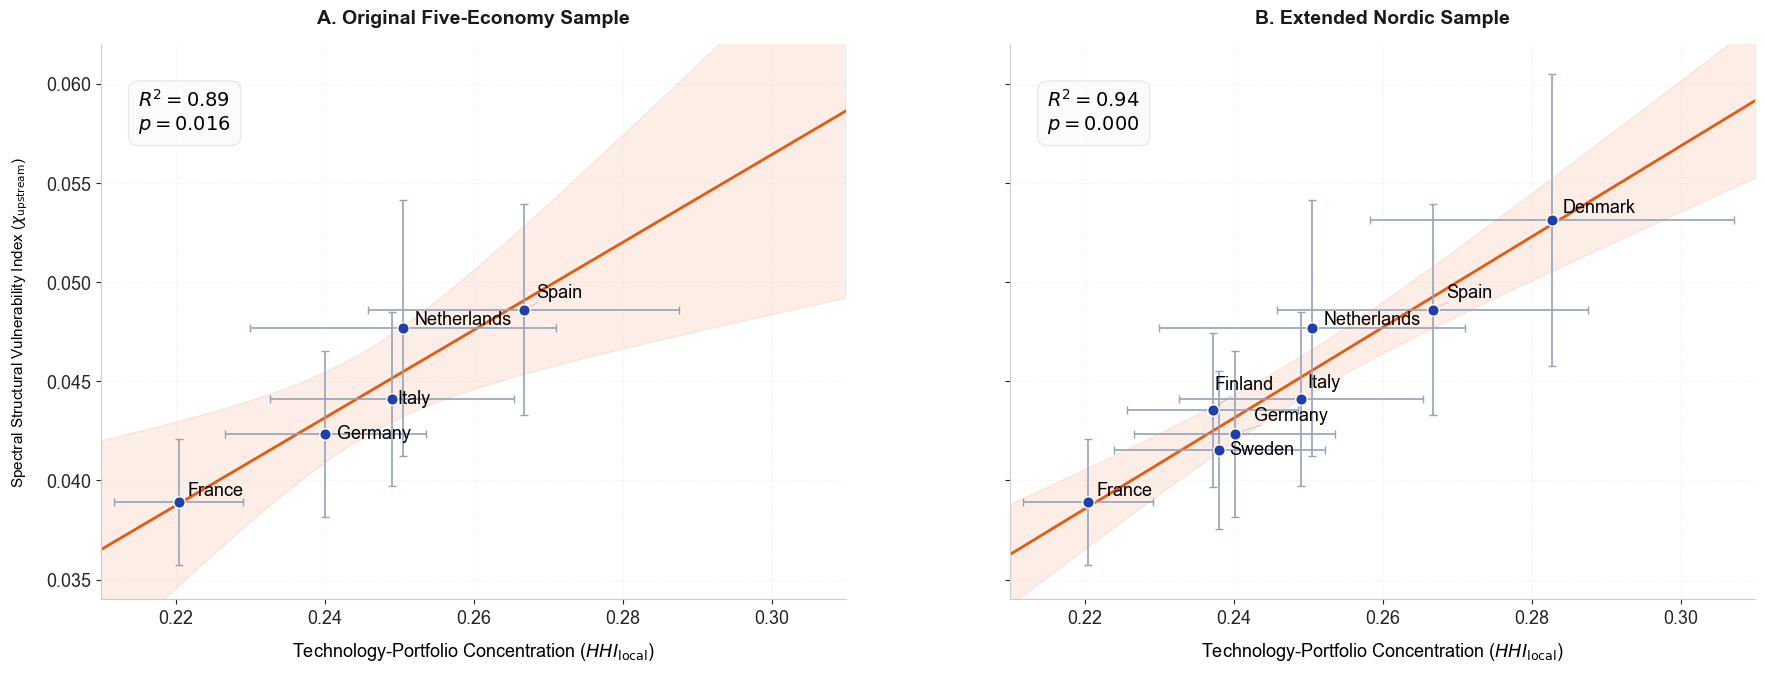

In [12]:
# ==========================================================
# Figure 9 B
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/Figure_Data/FigR1_R2_metric_comparison.csv"
df = pd.read_csv(DATA_DIR)

sample_specs = [
    {
        "sample": "baseline_5",
        "title": "A. Original Five-Economy Sample",
        "economies": ["France", "Germany", "Italy", "Netherlands", "Spain"],
    },
    {
        "sample": "extended_nordic_8",
        "title": "B. Extended Nordic Sample",
        "economies": ["France", "Germany", "Italy", "Netherlands", "Spain", "Sweden", "Denmark", "Finland"],
    },
]

# ==========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18.8, 7.5), sharey=True)

color_scatter = "#1e40af"
color_line = "#ea580c"
color_bars = "#94a3b8"

# ==========================================================
for ax, spec in zip(axes, sample_specs):

    sample_df = (
        df.loc[df["sample"] == spec["sample"]]
        .set_index("economy")
        .reindex(spec["economies"])
        .dropna(subset=["HHI_mean", "chi_mean"])
        .reset_index()
    )

    if sample_df.empty:
        raise ValueError(f"No observations found for sample '{spec['sample']}'.")

    x = sample_df["HHI_mean"].to_numpy()
    y = sample_df["chi_mean"].to_numpy()
    xerr = sample_df["HHI_std"].to_numpy()
    yerr = sample_df["chi_std"].to_numpy()

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2

    x_line = np.linspace(0.21, 0.31, 200)
    y_line = intercept + slope * x_line

    n = len(x)
    y_fitted = intercept + slope * x
    residual = y - y_fitted
    s_err = np.sqrt(np.sum(residual ** 2) / (n - 2))

    x_mean = np.mean(x)
    t_student = stats.t.ppf(0.975, df=n - 2)
    ci_band = t_student * s_err * np.sqrt(1 / n + (x_line - x_mean) ** 2 / np.sum((x - x_mean) ** 2))

    ax.fill_between(x_line, y_line - ci_band, y_line + ci_band, color=color_line, alpha=0.10, zorder=1)

    ax.plot(x_line, y_line, color=color_line, linewidth=2.0, zorder=2)

    ax.errorbar(
        x, y, xerr=xerr, yerr=yerr, fmt="o", color=color_scatter,
        ecolor=color_bars, elinewidth=1.2, capsize=3, capthick=1.2,
        markersize=8.3, mfc=color_scatter, mec="white", mew=1.0,
        linestyle="none", zorder=3
    )

    texts = []
    for _, row in sample_df.iterrows():
        texts.append(
            ax.text(row["HHI_mean"], row["chi_mean"], row["economy"], fontsize=13, fontweight="medium")
        )

    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#94a3b8", alpha=0.5, linewidth=0.7))

    stats_text = rf"$R^2 = {r_squared:.2f}$" + "\n" + rf"$p = {p_value:.3f}$"
    ax.text(
        0.05, 0.92, stats_text, transform=ax.transAxes,
        ha="left", va="top", fontsize=14, fontweight="semibold",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#fafafa", edgecolor="#e5e5e5", alpha=0.8)
    )

    ax.set_title(spec["title"], fontsize=14, fontweight="bold", pad=15, color="#1a1a1a")
    ax.set_xlabel(r"Technology-Portfolio Concentration ($HHI_{\mathrm{local}}$)", fontsize=13, labelpad=10)
    ax.grid(True, linestyle=":", alpha=0.3, color="#cccccc")
    ax.tick_params(axis="both", labelsize=13, colors="#262626")
    ax.set_xlim(0.21, 0.31)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#cccccc")

axes[0].set_ylabel(r"Spectral Structural Vulnerability Index ($\chi_{\mathrm{upstream}}$)", fontsize=11, labelpad=12)
axes[0].set_ylim(0.034, 0.062)

# ==========================================================
plt.subplots_adjust(
    wspace=0.22,
    bottom=0.14,
    top=0.88,
    left=0.08,
    right=0.96
)

plt.show()



Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


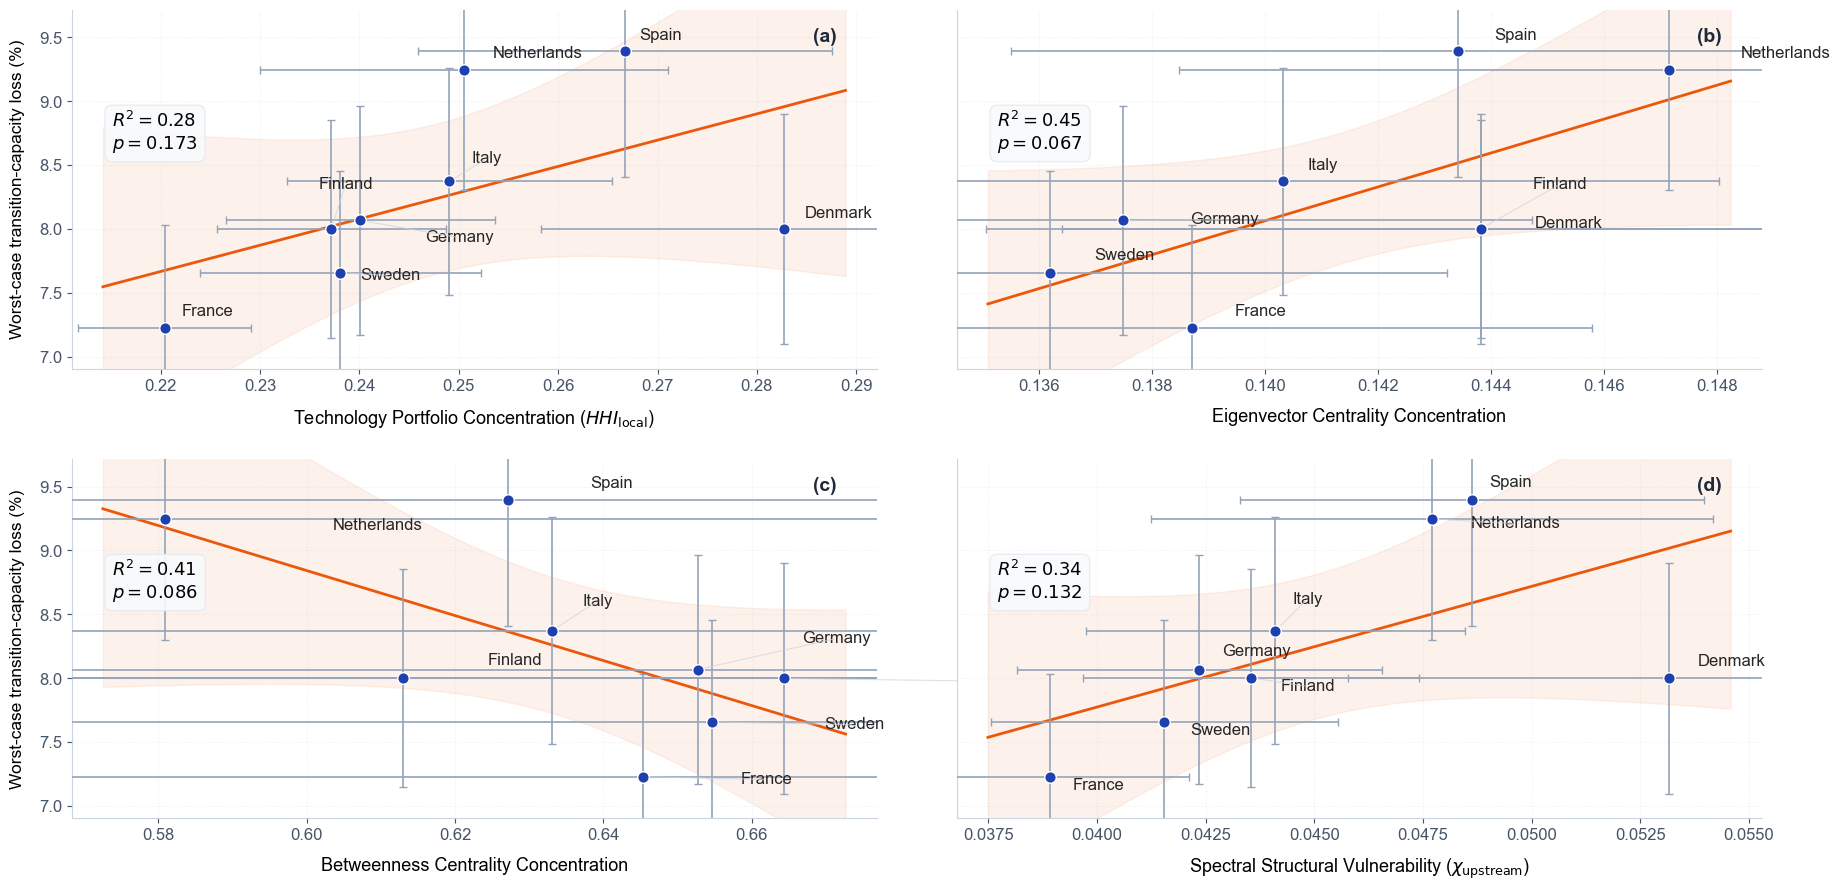

In [13]:
# ==========================================================
# Figure 10
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/F10_Predictive_comparison_of_conventional_and_network_metrics.csv"

df = pd.read_csv(DATA_DIR)

economy_order = ["France", "Germany", "Italy", "Netherlands", "Spain", "Sweden", "Denmark", "Finland"]

plot_df = (
    df.loc[df["sample"] == "extended_nordic_8"]
    .set_index("economy")
    .reindex(economy_order)
    .reset_index()
)

# ==========================================================
panel_specs = [
    {
        "letter": "a",
        "x_column": "HHI_mean",
        "x_std_column": "HHI_std",
        "x_label": r"Technology Portfolio Concentration ($HHI_{\mathrm{local}}$)",
    },
    {
        "letter": "b",
        "x_column": "eigenvector_concentration_mean",
        "x_std_column": "eigenvector_concentration_std",
        "x_label": r"Eigenvector Centrality Concentration",
    },
    {
        "letter": "c",
        "x_column": "betweenness_concentration_mean",
        "x_std_column": "betweenness_concentration_std",
        "x_label": r"Betweenness Centrality Concentration",
    },
    {
        "letter": "d",
        "x_column": "chi_mean",
        "x_std_column": "chi_std",
        "x_label": r"Spectral Structural Vulnerability ($\chi_{\mathrm{upstream}}$)",
    },
]

# ==========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(19.2, 9.4), sharey=True)
axes = axes.flatten()

color_scatter = "#1e40af"
color_line = "#ea580c"
color_bars = "#94a3b8"

y = plot_df["worstcase_loss_pct_mean"].to_numpy(dtype=float)
y_std = plot_df["worstcase_loss_pct_std"].to_numpy(dtype=float)

# ==========================================================

for i, (ax, spec) in enumerate(zip(axes, panel_specs)):
    x = plot_df[spec["x_column"]].to_numpy(dtype=float)
    x_std = plot_df[spec["x_std_column"]].to_numpy(dtype=float)

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2

    x_range_val = x.max() - x.min()
    x_line = np.linspace(x.min() - 0.1 * x_range_val, x.max() + 0.1 * x_range_val, 300)
    y_line = intercept + slope * x_line

    n = len(x)
    y_fitted = intercept + slope * x
    residual = y - y_fitted
    s_err = np.sqrt(np.sum(residual ** 2) / (n - 2))
    x_mean = np.mean(x)
    t_student = stats.t.ppf(0.975, df=n - 2)
    ci_band = t_student * s_err * np.sqrt(1 / n + (x_line - x_mean) ** 2 / np.sum((x - x_mean) ** 2))

    ax.fill_between(x_line, y_line - ci_band, y_line + ci_band, color=color_line, alpha=0.08, zorder=1)
    ax.plot(x_line, y_line, color=color_line, linewidth=2.0, zorder=2, label="OLS Regression")

    ax.errorbar(
        x, y, xerr=x_std, yerr=y_std, fmt="o", color=color_scatter,
        ecolor=color_bars, elinewidth=1.2, capsize=3, capthick=1.2,
        markersize=8.3, mfc=color_scatter, mec="white", mew=1.0,
        linestyle="none", zorder=3
    )

    texts = []
    for idx, row in plot_df.iterrows():
        texts.append(
            ax.text(
                row[spec["x_column"]],
                row["worstcase_loss_pct_mean"],
                row["economy"],
                fontsize=12.,
                fontweight="medium",
                color="#262626"
            )
        )
    adjust_text(
        texts,
        ax=ax,
        x=x,
        y=y,
        arrowprops=dict(arrowstyle="-", color="#cbd5e1", alpha=0.7, linewidth=0.8),
        expand_text=(1.2, 1.3),
        force_text=(0.2, 0.4)
    )

    stats_text = rf"$R^2 = {r_squared:.2f}$" + "\n" + rf"$p = {p_value:.3f}$"
    ax.text(
        0.05, 0.72, stats_text, transform=ax.transAxes,
        ha="left", va="top", fontsize=13, fontweight="semibold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f8fafc", edgecolor="#e2e8f0", alpha=0.9, linewidth=0.8)
    )

    ax.text(
        0.95, 0.95, f"({spec['letter']})", transform=ax.transAxes,
        ha="right", va="top", fontsize=14, fontweight="bold", color="#1e293b"
    )

    ax.set_xlabel(spec["x_label"], fontsize=13, labelpad=10, fontweight="medium")
    ax.grid(True, linestyle=":", alpha=0.3, color="#cccccc")
    ax.tick_params(axis="both", labelsize=12, colors="#475569")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#cbd5e1")
        ax.spines[spine].set_linewidth(0.8)

    ax.set_xlim(x.min() - 0.15 * x_range_val, x.max() + 0.15 * x_range_val)

y_min, y_max = y.min(), y.max()
y_range = y_max - y_min
for idx, ax in enumerate(axes):
    ax.set_ylim(y_min - 0.15 * y_range, y_max + 0.15 * y_range)

    if idx % 2 == 0:
        ax.set_ylabel("Worst-case transition-capacity loss (%)", fontsize=12.5, labelpad=10, fontweight="medium")
    else:
        ax.tick_params(axis="y", which="both", left=False, labelleft=False)

# ==========================================================
plt.subplots_adjust(
    wspace=0.10,
    hspace=0.25,
    bottom=0.08,
    top=0.94,
    left=0.08,
    right=0.96
)

plt.show()



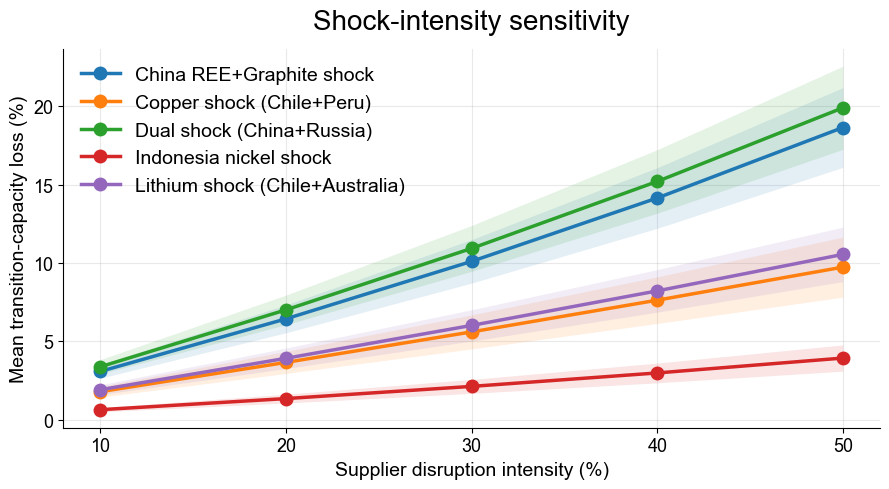

In [14]:
# ==========================================================
# Figure 11
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/F11_Shock_intensity_sensitivity_in_the_extended_Nordic_sample.csv"

df = pd.read_csv(DATA_DIR)

required_columns = {
    "sample",
    "intensity",
    "scenario",
    "loss_mean",
    "loss_sd",
}

missing_columns = required_columns.difference(df.columns)

numeric_columns = [
    "intensity",
    "loss_mean",
    "loss_sd",
]


# ==========================================================
# Select the extended Nordic sample
# ==========================================================

plot_df = df.loc[df["sample"] == "extended_nordic_8"].copy()


# Convert intensities from proportions to percentages
plot_df["intensity_pct"] = 100.0 * plot_df["intensity"]

# ==========================================================
# Scenario ordering
# ==========================================================

scenario_order = [
    "China REE+Graphite shock",
    "Copper shock (Chile+Peru)",
    "Dual shock (China+Russia)",
    "Indonesia nickel shock",
    "Lithium shock (Chile+Australia)",
]

missing_scenarios = [
    scenario
    for scenario in scenario_order
    if scenario not in plot_df["scenario"].unique()
]

plot_df["scenario"] = pd.Categorical(
    plot_df["scenario"],
    categories=scenario_order,
    ordered=True,
)

plot_df = plot_df.sort_values(
    ["scenario", "intensity_pct"]
)

# Verify that each scenario has one observation per intensity
duplicates = plot_df.duplicated(
    subset=["scenario", "intensity_pct"],
    keep=False,
)


# ==========================================================
# Plot
# ==========================================================

fig, ax = plt.subplots(figsize=(9., 5.))

for scenario in scenario_order:

    subset = (
        plot_df.loc[plot_df["scenario"] == scenario]
        .sort_values("intensity_pct")
    )

    x = subset["intensity_pct"].to_numpy(dtype=float)
    y = subset["loss_mean"].to_numpy(dtype=float)
    sd = subset["loss_sd"].to_numpy(dtype=float)

    # Mean loss curve
    line = ax.plot(
        x,
        y,
        marker="o",
        markersize=9,
        linewidth=2.5,
        label=scenario,
    )[0]

    ax.fill_between(
        x,
        y - sd,
        y + sd,
        alpha=0.12,
        color=line.get_color(),
        linewidth=0,
    )

# ==========================================================

ax.set_title(
    "Shock-intensity sensitivity",
    fontsize=20,
    pad=14,
)

ax.set_xlabel(
    "Supplier disruption intensity (%)",
    fontsize=14,
)

ax.set_ylabel(
    "Mean transition-capacity loss (%)",
    fontsize=14,
)

ax.set_xticks(
    sorted(plot_df["intensity_pct"].unique())
)

ax.tick_params(
    axis="both",
    labelsize=13,
)

# ==========================================================

x_min = plot_df["intensity_pct"].min()
x_max = plot_df["intensity_pct"].max()

ax.set_xlim(
    x_min - 2,
    x_max + 2,
)

upper_bound = (
    plot_df["loss_mean"]
    + plot_df["loss_sd"]
).max()

lower_bound = (
    plot_df["loss_mean"]
    - plot_df["loss_sd"]
).min()

ax.set_ylim(
    min(-0.5, lower_bound - 0.3),
    1.05 * upper_bound,
)

# ==========================================================

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=14,
)

ax.grid(
    alpha=0.28,
    linewidth=0.8,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ==========================================================

fig.tight_layout()

plt.show()



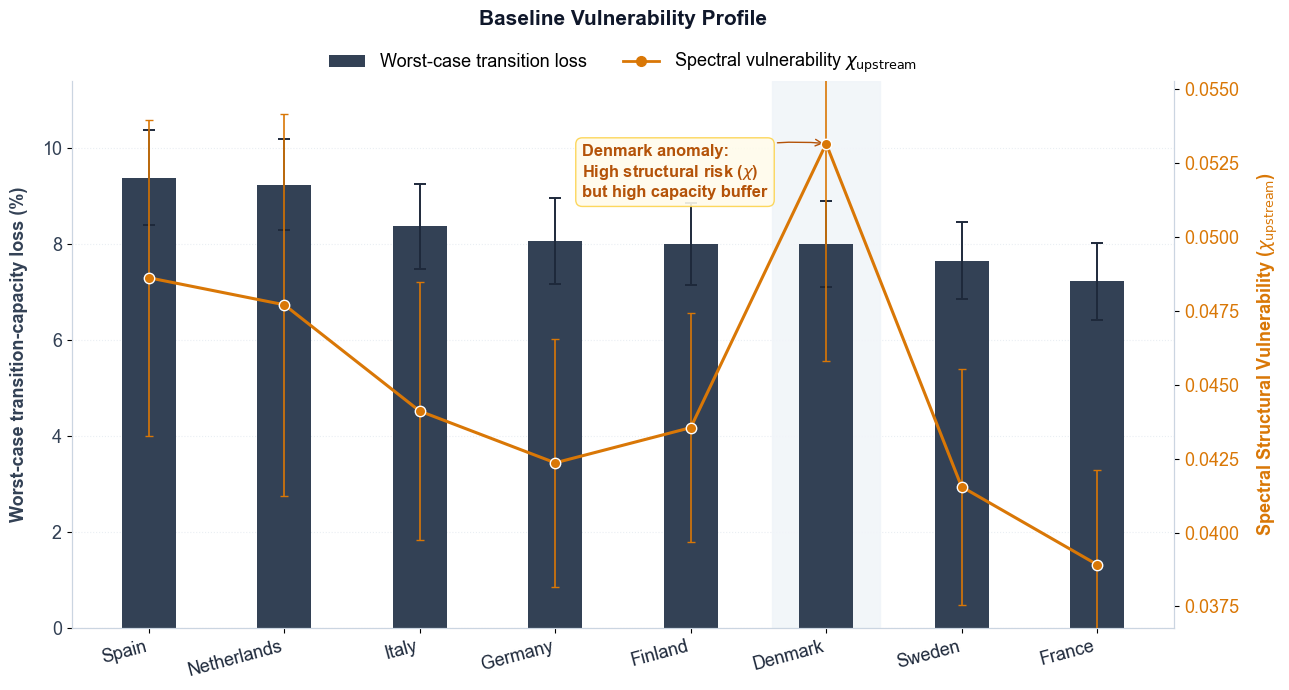

In [15]:
# ==========================================================
# Figure 12
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/F12_Baseline_vulnerability_in_the_extended_Nordic_sample.csv"

df = pd.read_csv(DATA_DIR)

plot_df = df.loc[df["sample"] == "extended_nordic_8"].copy()
plot_df = plot_df.sort_values("worstcase_loss_pct_mean", ascending=False).reset_index(drop=True)

x = np.arange(len(plot_df))

# ==========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

fig, ax_loss = plt.subplots(figsize=(13, 7),)
ax_chi = ax_loss.twinx()

color_bars = "#334155"
color_line = "#d97706"
color_highlight = "#f1f5f9"

idx_denmark = plot_df[plot_df["economy"] == "Denmark"].index[0]
ax_loss.axvspan(idx_denmark - 0.4, idx_denmark + 0.4, color=color_highlight, zorder=1, alpha=0.9)

bars = ax_loss.bar(
    x,
    plot_df["worstcase_loss_pct_mean"],
    width=0.4,
    yerr=plot_df["worstcase_loss_pct_std"],
    capsize=4,
    color=color_bars,
    edgecolor="none",
    error_kw={"elinewidth": 1.4, "capthick": 1.4, "ecolor": "#1e293b"},
    zorder=2,
)

line_err = ax_chi.errorbar(
    x,
    plot_df["chi_mean"],
    yerr=plot_df["chi_std"],
    fmt="o-",
    color=color_line,
    ecolor=color_line,
    elinewidth=1.2,
    capsize=3,
    markersize=7.5,
    linewidth=2.2,
    mfc=color_line,
    mec="white",
    mew=1.0,
    zorder=4,
)

ax_chi.annotate(
    "Denmark anomaly:\nHigh structural risk ($\\chi$)\nbut high capacity buffer",
    xy=(idx_denmark, plot_df.loc[idx_denmark, "chi_mean"]),
    xytext=(idx_denmark - 1.8, plot_df.loc[idx_denmark, "chi_mean"] - 0.0018),
    fontsize=11.8,
    fontweight="semibold",
    color="#b45309",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#fffbeb", edgecolor="#fcd34d", alpha=0.9),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.15", color="#b45309", linewidth=1.0)
)
# ==========================================================
ax_loss.set_xticks(x)
ax_loss.set_xticklabels(
    plot_df["economy"],
    rotation=15,
    ha="right",
    fontsize=13,
    fontweight="medium",
    color="#1e293b"
)

ax_loss.set_ylabel("Worst-case transition-capacity loss (%)", fontsize=13, fontweight="bold", color=color_bars, labelpad=10)
ax_loss.tick_params(axis="y", labelsize=13, labelcolor=color_bars)
loss_upper = (plot_df["worstcase_loss_pct_mean"] + plot_df["worstcase_loss_pct_std"]).max()
ax_loss.set_ylim(0, max(11.0, 1.1 * loss_upper))

ax_chi.set_ylabel(r"Spectral Structural Vulnerability ($\chi_{\mathrm{upstream}}$)", fontsize=13, fontweight="bold", color=color_line, labelpad=12)
ax_chi.tick_params(axis="y", labelsize=13, labelcolor=color_line)
chi_min = plot_df["chi_mean"].min()
chi_max = plot_df["chi_mean"].max()
chi_range = chi_max - chi_min
ax_chi.set_ylim(chi_min - 0.15 * chi_range, chi_max + 0.15 * chi_range)

ax_loss.grid(axis="y", linestyle=":", alpha=0.4, color="#cbd5e1")
ax_loss.set_axisbelow(True)

for ax in [ax_loss, ax_chi]:
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_color("#cbd5e1")
    ax.spines["bottom"].set_color("#cbd5e1")
    ax.spines["right"].set_color("#cbd5e1")

# ==========================================================
legend_handles = [
    Patch(facecolor=color_bars, edgecolor="none", label="Worst-case transition loss"),
    Line2D([0], [0], color=color_line, marker="o", linewidth=2.0, markersize=7, label=r"Spectral vulnerability $\chi_{\mathrm{upstream}}$"),
]

ax_loss.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False,
    fontsize=13
)

ax_loss.set_title("Baseline Vulnerability Profile", fontsize=15, fontweight="bold", pad=40, color="#0f172a")

plt.tight_layout()
plt.show()



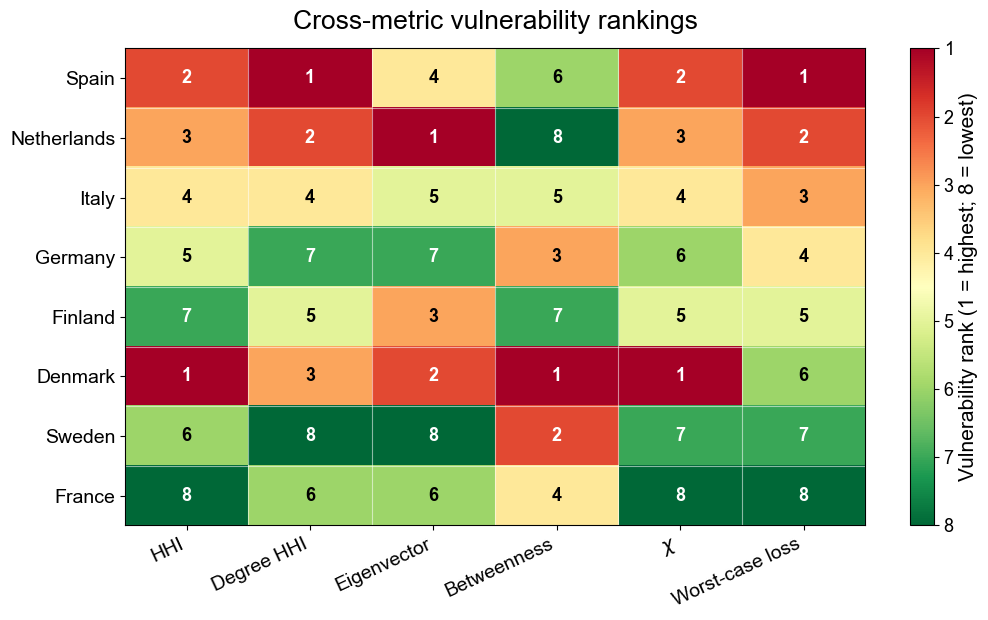

In [16]:
# ==========================================================
# Figure 13
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/F13_Cross_metric_vulnerability_rankings_in_the_extended_sample.csv"

df = pd.read_csv(DATA_DIR)

required_columns = {
    "sample",
    "economy",
    "rank_HHI",
    "rank_weighted_degree_hhi",
    "rank_eigenvector_concentration",
    "rank_betweenness_concentration",
    "rank_chi",
    "rank_worstcase_loss_pct",
}

missing_columns = required_columns.difference(df.columns)



rank_columns = [
    "rank_HHI",
    "rank_weighted_degree_hhi",
    "rank_eigenvector_concentration",
    "rank_betweenness_concentration",
    "rank_chi",
    "rank_worstcase_loss_pct",
]


# ==========================================================

plot_df = df.loc[df["sample"] == "extended_nordic_8"].copy()

# ==========================================================

n_economies = plot_df["economy"].nunique()

for column in rank_columns:

    values = plot_df[column].to_numpy(dtype=float)

    if np.any(values < 1) or np.any(values > n_economies):
        raise ValueError(
            f"Column '{column}' contains ranks outside "
            f"the admissible range [1, {n_economies}]."
        )

    expected_ranks = set(range(1, n_economies + 1))
    observed_ranks = set(values.astype(int))

    if observed_ranks != expected_ranks:
        raise ValueError(
            f"Column '{column}' does not contain a complete "
            f"ranking from 1 to {n_economies}. "
            f"Observed ranks: {sorted(observed_ranks)}"
        )

# ==========================================================

plot_df = (
    plot_df
    .sort_values(
        "rank_worstcase_loss_pct",
        ascending=True,
    )
    .reset_index(drop=True)
)

economy_order = plot_df["economy"].tolist()

# ==========================================================

metric_columns = [
    "rank_HHI",
    "rank_weighted_degree_hhi",
    "rank_eigenvector_concentration",
    "rank_betweenness_concentration",
    "rank_chi",
    "rank_worstcase_loss_pct",
]

metric_labels = [
    "HHI",
    "Degree HHI",
    "Eigenvector",
    "Betweenness",
    r"$\chi$",
    "Worst-case loss",
]

rank_matrix = plot_df[metric_columns].to_numpy(dtype=float)

# ==========================================================

fig, ax = plt.subplots(figsize=(10, 6.3))

cmap = plt.get_cmap("RdYlGn")
norm = Normalize(vmin=1, vmax=n_economies)

image = ax.imshow(
    rank_matrix,
    cmap=cmap,
    norm=norm,
    aspect="auto",
)

# ==========================================================

ax.set_xticks(np.arange(len(metric_labels)))
ax.set_xticklabels(
    metric_labels,
    rotation=25,
    ha="right",
    fontsize=14,
)

ax.set_yticks(np.arange(len(economy_order)))
ax.set_yticklabels(
    economy_order,
    fontsize=14,
)

ax.set_title(
    "Cross-metric vulnerability rankings",
    fontsize=19,
    pad=14,
)

# ==========================================================

for i in range(rank_matrix.shape[0]):
    for j in range(rank_matrix.shape[1]):

        rank_value = int(round(rank_matrix[i, j]))

        rgba = cmap(norm(rank_value))

        luminance = (
            0.2126 * rgba[0]
            + 0.7152 * rgba[1]
            + 0.0722 * rgba[2]
        )

        text_color = "black" if luminance > 0.55 else "white"

        ax.text(
            j,
            i,
            f"{rank_value}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="semibold",
            color=text_color,
        )

# ==========================================================

ax.set_xticks(
    np.arange(-0.5, len(metric_labels), 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, len(economy_order), 1),
    minor=True,
)

ax.grid(
    which="minor",
    color="white",
    linewidth=0.8,
    alpha=0.55,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

# ==========================================================

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.055,
)

colorbar.set_ticks(np.arange(1, n_economies + 1))

colorbar.set_label(
    "Vulnerability rank (1 = highest; 8 = lowest)",
    fontsize=15,)

colorbar.ax.tick_params(labelsize=13)

colorbar.ax.invert_yaxis()

# ==========================================================

fig.tight_layout()

plt.show()



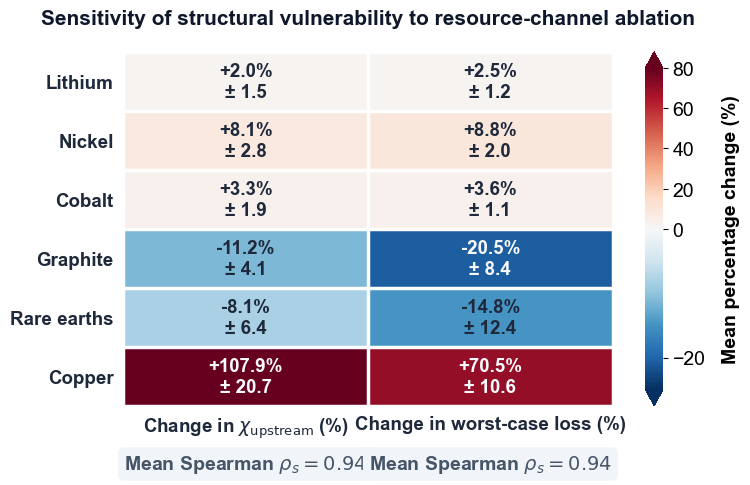

In [17]:
# ==========================================================
# Figure 14
# ==========================================================

DATA_DIR = "C:/Users/fredy/Downloads/Results_Geo_V10/00_Manuscript/Main_Figure_Data/F14_Leave_one_resource_out_robustness.csv"
df = pd.read_csv(DATA_DIR)

# ==========================================================

plot_df = df.loc[
    (df["sample"] == "extended_nordic_8")
    & df["specification"].str.startswith("Without ")
    ].copy()

specification_order = [
    "Without Lithium",
    "Without Nickel",
    "Without Cobalt",
    "Without Graphite",
    "Without Rare earths",
    "Without Copper",
]

plot_df = plot_df.set_index("specification").reindex(specification_order).reset_index()
plot_df["resource"] = plot_df["specification"].str.replace("Without ", "", regex=False)

matrix_mean = plot_df[["chi_change_mean", "loss_change_mean"]].to_numpy(dtype=float)
matrix_sd = plot_df[["chi_change_sd", "loss_change_sd"]].to_numpy(dtype=float)

# ==========================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(7.6, 5.))

norm = TwoSlopeNorm(
    vmin=-25.0,
    vcenter=0.0,
    vmax=80.0,
)

image = ax.imshow(
    matrix_mean,
    cmap="RdBu_r",
    norm=norm,
    aspect="auto",
    interpolation="nearest"
)

# ==========================================================

column_labels = [
    r"Change in $\chi_{\mathrm{upstream}}$ (%)",
    "Change in worst-case loss (%)",]
resource_labels = plot_df["resource"].tolist()

ax.set_xticks(np.arange(len(column_labels)))
ax.set_xticklabels(column_labels, fontsize=13.5, fontweight="bold", color="#1e293b")

ax.set_yticks(np.arange(len(resource_labels)))
ax.set_yticklabels(resource_labels, fontsize=13.5, fontweight="bold", color="#1e293b")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(np.arange(-0.5, len(column_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(resource_labels), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2.5)
ax.tick_params(which="both", bottom=False, left=False)

for i in range(matrix_mean.shape[0]):
    for j in range(matrix_mean.shape[1]):
        mean_val = matrix_mean[i, j]
        sd_val = matrix_sd[i, j]

        rgba = image.cmap(image.norm(mean_val))
        luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
        text_color = "#1e293b" if luminance > 0.52 else "#f8fafc"

        cell_text = f"{mean_val:+.1f}%\n± {sd_val:.1f}"

        ax.text(
            j, i, cell_text,
            ha="center", va="center",
            fontsize=13.5, fontweight="bold",
            color=text_color
        )

rho_chi = plot_df["rank_rho_chi_mean"].mean()
rho_loss = plot_df["rank_rho_loss_mean"].mean()

ax.text(
    0, len(resource_labels) - 0.5 + 0.8,
    rf"Mean Spearman $\rho_s = {rho_chi:.2f}$",
    ha="center", va="top", fontsize=14, fontweight="bold", color="#475569",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#f1f5f9", edgecolor="none")
)
ax.text(
    1, len(resource_labels) - 0.5 + 0.8,
    rf"Mean Spearman $\rho_s = {rho_loss:.2f}$",
    ha="center", va="top", fontsize=14, fontweight="bold", color="#475569",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#f1f5f9", edgecolor="none")
)

# ==========================================================

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.040,
    pad=0.06,
    extend="both"
)
colorbar.set_label("Mean percentage change (%)", fontsize=14., fontweight="bold", labelpad=12)
colorbar.ax.tick_params(labelsize=14)
colorbar.outline.set_visible(False)

ax.set_title("Sensitivity of structural vulnerability to resource-channel ablation", fontsize=15, fontweight="bold", pad=20, color="#0f172a")

plt.tight_layout()
plt.show()